## **Supplement to *Distilling the Knowledge in a Neural Network* (Hinton, et. al.)**

---

Created by: James Triveri  
Date: 2025-03-12  


Illya Sutskever, Geoffrey Hinton, Alex Krizhevsky (c. 2013):

<center>
<img src="images/hinton.jpg" width="600">
</center>


<center>
<img src="images/image-net.png" width="600">
</center>

### **Classical Bias-Variance Tradeoff:**

<center>
<img src="images/bias-variance-tradeoff.jpg" width="800">
</center>

- Bias measures how much a model systematically misses the true relationship. Simple models tend to have high bias because they impose strong assumptions about the data, leading to underfitting.

- Variance measures how sensitive a model is to fluctuations in the training data. Very flexible models tend to have high variance because they adapt too closely to the training set, leading to overfitting.

- The bias–variance trade-off reflects the balance between the two sources of error: increasing model complexity typically reduces bias but increases variance, and good modeling practice aims to find the level of complexity that minimizes total prediction error.

- Classical view: As model complexity increases, test error first decreases and then increases, producing the familiar U-shaped bias–variance curve. This suggests there is an optimal intermediate model complexity.

- Exchange student example.

From *Belkin*, et. al.:

> The bias-variance trade-off implies that a model should balance under-fitting and over-fitting: rich enough to express underlying structure in data, simple enough to avoid fitting spurious patterns.




### **Double Descent Curve:**


<center>
<img src="images/paper.png" width="800">
</center>

<br>

<center>
<img src="images/double-descent.png" width="800">
</center>


- Modern deep models often reach a point where they can perfectly fit the training data (zero training error). At this point, test error often spikes because the model is flexible enough to memorize noise.

- When model size continues to increase beyond the interpolation threshold, test error starts to decrease again. Extremely over-parameterized models can generalize well because optimization tends to find simpler, more structured solutions within the parameter space.
    - Having more parameters than data does not automatically cause over-fitting, because gradient-based optimization does not search the parameter space uniformly.


**TL;DR**

- Small models cannot represent the true function (high bias).

- Medium models can interpolate but may find unstable solutions (high variance).

- Very large models have so many valid interpolating solutions that optimization can settle on one of the simpler ones.








From *Belkin*, et. al.:

> *However, in the modern practice, very rich models such as neural networks are trained to exactly fit (i.e., interpolate)
the data. Classically, such models would be considered over-fit, and yet they often obtain high accuracy on test data. This apparent contradiction has raised questions about the mathematical foundations of machine learning and their relevance to practitioners.*

Knowledge distillation takes advantage of the double-descent phenomena. We can think of distillation as a compression mechanism for over-parameterized knowledge.


### **Terminology:**

- **Teacher Model** (Hinton refers to this as the "cumbersome" model), generally an extremely over-parameterized neural network dedicated to a specific classification task. In the paper, the task is to predict images of handwritten digits (MNIST). 

- **Student Model** (Hinton's "small" model) is a smaller, more efficient model trained to mimic the behavior and predictions of the teacher model, allowing it to approximate the teacher's performance with far fewer parameters.



### **Experimental Setup:**
1. Each MNIST sample is a 28x28 greyscale image, and each pixel is represented by a single byte (0-255). Each image is flattened into a 1x784 dimensional vector. 

2. Input vectors are passed into one or more hidden layers (matrix multiply), typically with non-linearities between.

3. Class activations (or "logits") represent the output of the network. There will be one output for each class in the original data (for MNIST, the goal is to predict which of the ten hand-written digits an image represents, so there will be 10 outputs).

4. Softmax converts the logits to a valid probability distribution over classes. 



#### **Simplified FCN Architecture:**

<center>
<img src="images/fcn.png" width="800">
</center>


#### **Sample MNIST Images:**

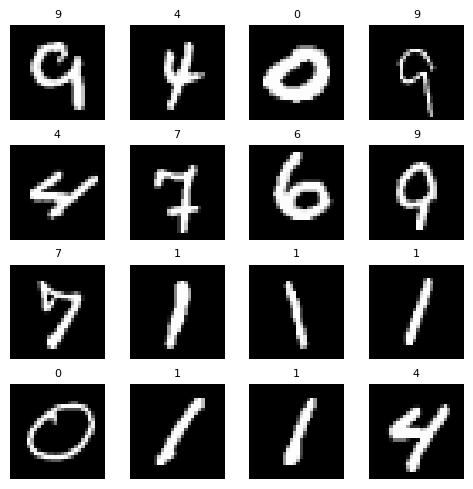

In [5]:
##### Load MNIST dataset and display a batch of images #####

import warnings

import numpy as np
import pandas as pd

import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid


np.set_printoptions(suppress=True, precision=5, linewidth=1000)
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option("display.precision", 5)
warnings.filterwarnings("ignore")

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([ToTensor(), v2.ToDtype(torch.float, scale=True)])
)

valid_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform= v2.Compose([ToTensor(), v2.ToDtype(torch.float, scale=True)])
)

valid_data, test_data = torch.utils.data.random_split(valid_data, [9000, 1000])
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=True)

fig = plt.figure(figsize=(5., 5.), tight_layout=False)
grid = ImageGrid(fig, 111, nrows_ncols=(4, 4), axes_pad=0.25)
X, y = next(iter(train_loader))
for ax, X_ii, y_ii in zip(grid, X, y):
    X_ii = np.transpose(X_ii.numpy(), (1, 2, 0))
    ax.imshow(X_ii, cmap="gray")
    ax.axis("off")
    ax.set_title(f"{y_ii}", fontsize=8)

plt.show()



<br>


#### **Softmax**

Softmax is a function that converts a vector of raw scores or logits into probabilities ("logits" refer to the raw, unnormalized output values produced by the last layer of a neural network before applying an activation function).

It is commonly used in classification tasks, particularly in the output layer of a neural network. It converts the raw logits into a probability distribution.

For a vector $z$ of length $n$, softmax is defined as:

$$
\sigma(z_i) = \frac{e^{z_i/T}}{\sum_{j=1}^{n} e^{z_j/T}},
$$

where:
- $e^{z_i}$ exponentiates each element.
- The denominator ensures all probabilities sum to 1.






In [23]:

def softmax(x, t=1):
    exp_x = np.exp(np.asarray(x) / t)
    return exp_x / exp_x.sum()


logits = [-.34, 0.12, 1.95, -0.56, .62, -0.23, 0.28, .89, 0.34, -0.85]
probs = softmax(logits)

print(f"logits     : {logits}")
print(f"sum(logits): {sum(logits):.3f}")
print(f"probs      : {[round(i, 3) for i in probs]}")
print(f"sum(probs) : {sum(probs):.3}")

logits     : [-0.34, 0.12, 1.95, -0.56, 0.62, -0.23, 0.28, 0.89, 0.34, -0.85]
sum(logits): 2.220
probs      : [0.04, 0.064, 0.397, 0.032, 0.105, 0.045, 0.075, 0.138, 0.079, 0.024]
sum(probs) : 1.0


#### **Hard Labels vs. Soft Labels**

Starting from the softmax, the predicted class is:

$$
\sigma^{*} = \arg\max_{\sigma} f(\sigma)
$$


```python
soft = [0.04, 0.064, 0.397, 0.032, 0.105, 0.045, 0.075, 0.138, 0.079, 0.024]
hard = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# Predicted class = index 2.
```



**The key idea is that the teacher's full probability distribution contains more information than a one-hot label. For example, a teacher may predict that an image is mostly a "3", but also somewhat resembles an "8". The student can learn from that structure and often generalizes better than if it were trained on hard labels alone.**



#### **Temperature Scaling in Softmax**

- When T=1, the softmax behaves normally. 

- Increasing the temperature (T>1) produces a softer, more diffuse probability distribution. Probability mass is spread more evenly across classes. 

- Decreasing the temperature (T<1) sharpens the distribution, concentrating probability on the most likely class. 

- In knowledge distillation, a higher temperature is often used so that the student model can learn from the teacher’s full distribution over classes rather than only the single most likely prediction.

<br>


<center>
<img src="images/temperature-scaling.png">
</center>


#### **The Mythical "3"**

The last layer of a neural network can be represented as:

$$
z = Wx + b,
$$



where:

$W$ = weight matrix   
$x$ = last hidden representation   
$b$ = bias vector (one bias per class)   
$z$ = logits before softmax     

For MNIST there are 10 classes, so $b$ has 10 elements:   

$$
b = [b_{1}, b_{2}, \dots, b_{10}]
$$

Since 3 wasn't in the training set of the student model, the learned bias was too low. When this was corrected (increasing to 3.5), even though the model never saw a 3, the feature extractor learned representations that still activate for 3-like shapes because those features were useful for other digits.

The model already learned features useful for recognizing 3s, even without seeing them. The only thing wrong was the prior probability (the bias term) for that class.

Distillation transferred structural knowledge about digit shapes, not just label memorization.




### **Knowledge Distillation and LLMs**

- [Everything you need to know about Knowledge Distillation](https://huggingface.co/blog/Kseniase/kd)

In the context of large language models, knowledge distillation works by training a smaller or cheaper model to imitate the behavior of a stronger model rather than learning directly from raw human-labeled data. The larger model (the “teacher,” such as GPT-4 in the case of Deep Seek) generates responses to a wide range of prompts. These responses implicitly encode a great deal of structure: reasoning style, formatting, preferred explanations, and patterns of language. A smaller model is then trained on those prompt–response pairs so that it learns to produce outputs similar to the teacher's. In effect, the student is learning the teacher's mapping from prompts to responses, compressing the capabilities of a very large model into a more efficient one. In modern LLM training pipelines this is often combined with other methods such as reinforcement learning from human feedback and additional curated datasets, but the distillation component allows much of the teacher model's behavior to be transferred into a model that is cheaper to run and easier to deploy.

- The original Deep Seek model was about a third of the size of GPT-4 in terms of parameter count.